In [267]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import mean_absolute_error ,r2_score , mean_squared_error

In [268]:
df = pd.read_csv("cardekho_dataset.csv")
df

,Unnamed: 0,car_name,brand,model,vehicle_age,km_driven,seller_type,fuel_type,transmission_type,mileage,engine,max_power,seats,selling_price
0,0,Maruti Alto,Maruti,Alto,9,120000,Individual,Petrol,Manual,19.70,796,46.30,5,120000
1,1,Hyundai Grand,Hyundai,Grand,5,20000,Individual,Petrol,Manual,18.90,1197,82.00,5,550000
2,2,Hyundai i20,Hyundai,i20,11,60000,Individual,Petrol,Manual,17.00,1197,80.00,5,215000
3,3,Maruti Alto,Maruti,Alto,9,37000,Individual,Petrol,Manual,20.92,998,67.10,5,226000
4,4,Ford Ecosport,Ford,Ecosport,6,30000,Dealer,Diesel,Manual,22.77,1498,98.59,5,570000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15406,19537,Hyundai i10,Hyundai,i10,9,10723,Dealer,Petrol,Manual,19.81,1086,68.05,5,250000
15407,19540,Maruti Ertiga,Maruti,Ertiga,2,18000,Dealer,Petrol,Manual,17.50,1373,91.10,7,925000
15408,19541,Skoda Rapid,Skoda,Rapid,6,67000,Dealer,Diesel,Manual,21.14,1498,103.52,5,425000
15409,19542,Mahindra XUV500,Mahindra,XUV500,5,3800000,Dealer,Diesel,Manual,16.00,2179,140.00,7,1225000


In [269]:
df.size

215754

In [270]:
df.shape


(15411, 14)

In [271]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15411 entries, 0 to 15410
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Unnamed: 0         15411 non-null  int64  
 1   car_name           15411 non-null  object 
 2   brand              15411 non-null  object 
 3   model              15411 non-null  object 
 4   vehicle_age        15411 non-null  int64  
 5   km_driven          15411 non-null  int64  
 6   seller_type        15411 non-null  object 
 7   fuel_type          15411 non-null  object 
 8   transmission_type  15411 non-null  object 
 9   mileage            15411 non-null  float64
 10  engine             15411 non-null  int64  
 11  max_power          15411 non-null  float64
 12  seats              15411 non-null  int64  
 13  selling_price      15411 non-null  int64  
dtypes: float64(2), int64(6), object(6)
memory usage: 1.6+ MB


In [272]:
df.dtypes

,0
Unnamed: 0,int64
car_name,object
brand,object
model,object
vehicle_age,int64
km_driven,int64
seller_type,object
fuel_type,object
transmission_type,object
mileage,float64


In [273]:
df.isnull().sum()

,0
Unnamed: 0,0
car_name,0
brand,0
model,0
vehicle_age,0
km_driven,0
seller_type,0
fuel_type,0
transmission_type,0
mileage,0


In [274]:
df.duplicated().sum()

np.int64(0)

In [275]:
df.drop(columns = ["Unnamed: 0"], inplace=True)

In [276]:
df.drop(columns = ["car_name"], inplace=True)

In [277]:
df.describe()

,vehicle_age,km_driven,mileage,engine,max_power,seats,selling_price
count,15411.000000,1.541100e+04,15411.000000,15411.000000,15411.000000,15411.000000,1.541100e+04
mean,6.036338,5.561648e+04,19.701151,1486.057751,100.588254,5.325482,7.749711e+05
std,3.013291,5.161855e+04,4.171265,521.106696,42.972979,0.807628,8.941284e+05
min,0.000000,1.000000e+02,4.000000,793.000000,38.400000,0.000000,4.000000e+04
25%,4.000000,3.000000e+04,17.000000,1197.000000,74.000000,5.000000,3.850000e+05
50%,6.000000,5.000000e+04,19.670000,1248.000000,88.500000,5.000000,5.560000e+05
75%,8.000000,7.000000e+04,22.700000,1582.000000,117.300000,5.000000,8.250000e+05
max,29.000000,3.800000e+06,33.540000,6592.000000,626.000000,9.000000,3.950000e+07


In [278]:
df[df["seats"]==0]

,brand,model,vehicle_age,km_driven,seller_type,fuel_type,transmission_type,mileage,engine,max_power,seats,selling_price
3217,Honda,City,18,40000,Individual,Petrol,Manual,13.00,1493,100.00,0,115000
12619,Nissan,Kicks,2,10000,Individual,Diesel,Manual,19.39,1461,108.49,0,1154000


In [279]:
df["seats"] = df["seats"].replace(0, 5)

In [280]:
numerical_columns = [
    "vehicle_age",
    "km_driven",
    "mileage",
    "engine",
    "max_power",
    "seats",
    "selling_price"
]

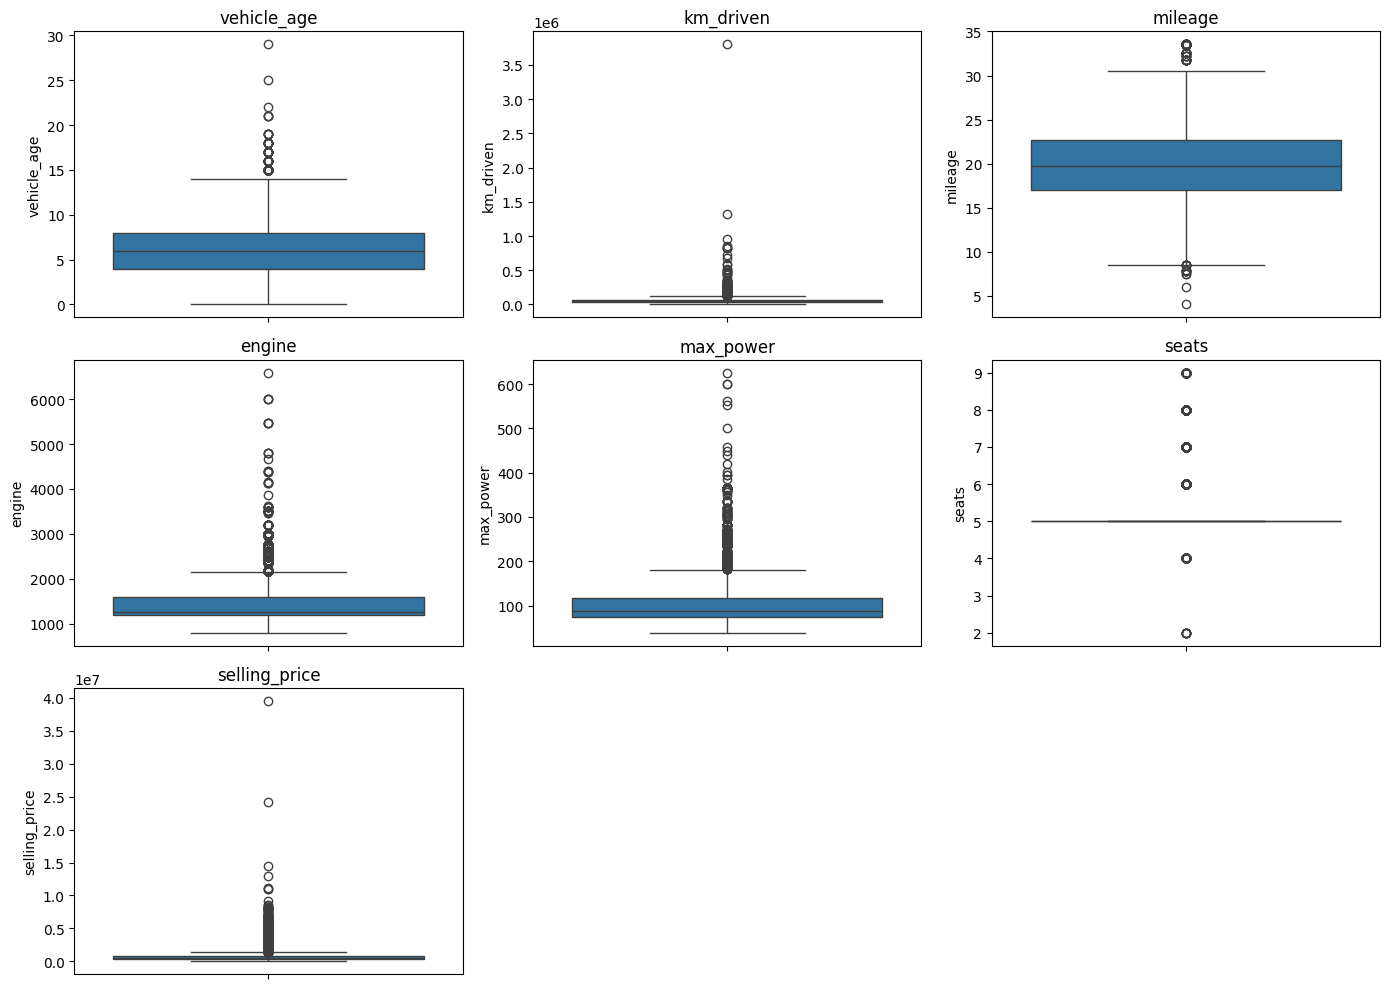

In [281]:
plt.figure(figsize=(14,10))

for i, column in enumerate(numerical_columns, 1):
    plt.subplot(3, 3, i)
    sns.boxplot(y=df[column])
    plt.title(column)

plt.tight_layout()
plt.show()

In [282]:
max_km = df[df["km_driven"]== df["km_driven"].max()]
max_km

,brand,model,vehicle_age,km_driven,seller_type,fuel_type,transmission_type,mileage,engine,max_power,seats,selling_price
15409,Mahindra,XUV500,5,3800000,Dealer,Diesel,Manual,16.0,2179,140.0,7,1225000


In [283]:
max_price = df[df["selling_price"] == df["selling_price"].max()]
max_price

,brand,model,vehicle_age,km_driven,seller_type,fuel_type,transmission_type,mileage,engine,max_power,seats,selling_price
3799,Ferrari,GTC4Lusso,2,3800,Dealer,Petrol,Automatic,4.0,3855,601.0,4,39500000


In [284]:
df = df[df["km_driven"] <= 1000000]

In [285]:
df.nunique()

,0
brand,32
model,120
vehicle_age,24
km_driven,3686
seller_type,3
fuel_type,5
transmission_type,2
mileage,411
engine,110
max_power,342


In [286]:
df["model"].value_counts()

,count
model,
i20,906
Swift Dzire,890
Swift,781
Alto,778
City,757
...,...
Altroz,1
C,1
Ghost,1


In [287]:
df["brand"].value_counts()

,count
brand,
Maruti,4992
Hyundai,2982
Honda,1485
Mahindra,1010
Toyota,793
Ford,790
Volkswagen,620
Renault,536
BMW,439


In [288]:
premium_brands = [
    "Audi",
    "BMW",
    "Mercedes-Benz",
    "Mercedes-AMG",
    "Jaguar",
    "Land Rover",
    "Lexus",
    "Porsche",
    "Volvo",
    "Bentley",
    "Rolls-Royce",
    "Ferrari",
    "Maserati",
    "Mini"
]

In [289]:
df["is_premium"] = (
    df["brand"].isin(premium_brands)
).astype(int)

/tmp/ipykernel_2257/557739056.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["is_premium"] = (


In [290]:
df["brand"] = df["brand"].replace({
    "ISUZU": "Isuzu"
})

/tmp/ipykernel_2257/2542440739.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["brand"] = df["brand"].replace({


In [291]:
df["km_per_year"] = df["km_driven"] / (df["vehicle_age"] + 1)
df["km_per_year"]

/tmp/ipykernel_2257/4134587496.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["km_per_year"] = df["km_driven"] / (df["vehicle_age"] + 1)


,km_per_year
0,12000.000000
1,3333.333333
2,5000.000000
3,3700.000000
4,4285.714286
...,...
15405,1538.166667
15406,1072.300000
15407,6000.000000
15408,9571.428571


In [292]:
df["power_per_cc"] = (df["max_power"] / df["engine"])*1000
df["power_per_cc"]

/tmp/ipykernel_2257/2135931200.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["power_per_cc"] = (df["max_power"] / df["engine"])*1000


,power_per_cc
0,58.165829
1,68.504595
2,66.833751
3,67.234469
4,65.814419
...,...
15405,68.504595
15406,62.661142
15407,66.351056
15408,69.105474


<Axes: xlabel='selling_price', ylabel='Count'>

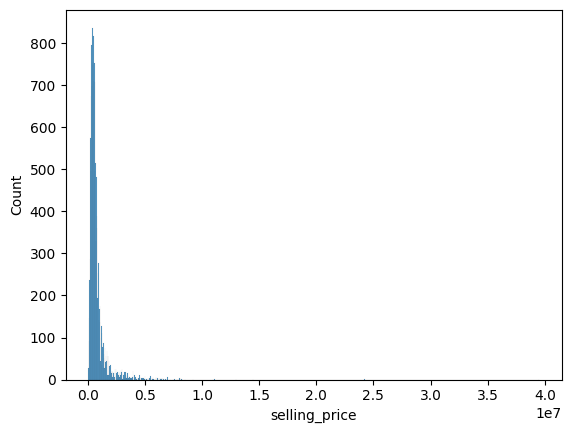

In [293]:
sns.histplot(df["selling_price"])

<Axes: >

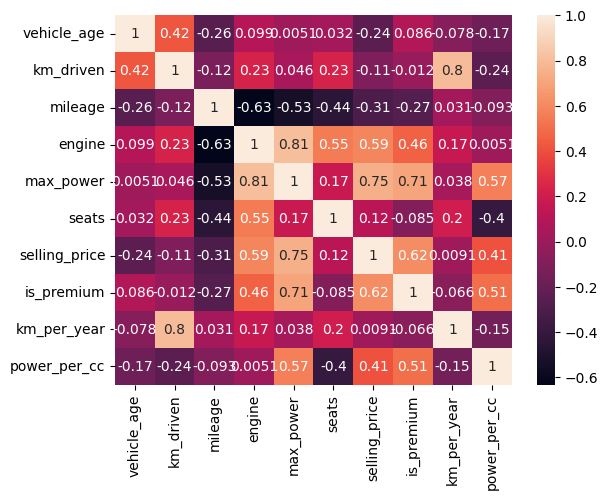

In [294]:
sns.heatmap(df.corr(numeric_only=True), annot=True)

In [295]:
LabelEncoder()

LabelEncoder()

In [296]:
df.head()

,brand,model,vehicle_age,km_driven,seller_type,fuel_type,transmission_type,mileage,engine,max_power,seats,selling_price,is_premium,km_per_year,power_per_cc
0,Maruti,Alto,9,120000,Individual,Petrol,Manual,19.70,796,46.30,5,120000,0,12000.000000,58.165829
1,Hyundai,Grand,5,20000,Individual,Petrol,Manual,18.90,1197,82.00,5,550000,0,3333.333333,68.504595
2,Hyundai,i20,11,60000,Individual,Petrol,Manual,17.00,1197,80.00,5,215000,0,5000.000000,66.833751
3,Maruti,Alto,9,37000,Individual,Petrol,Manual,20.92,998,67.10,5,226000,0,3700.000000,67.234469
4,Ford,Ecosport,6,30000,Dealer,Diesel,Manual,22.77,1498,98.59,5,570000,0,4285.714286,65.814419


In [297]:
encoder = LabelEncoder()

df["fuel_type"] = encoder.fit_transform(df["fuel_type"])

/tmp/ipykernel_2257/2398094141.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["fuel_type"] = encoder.fit_transform(df["fuel_type"])


In [298]:
df["transmission_type"] = encoder.fit_transform(df["transmission_type"])

/tmp/ipykernel_2257/1205572872.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["transmission_type"] = encoder.fit_transform(df["transmission_type"])


In [299]:
df["seller_type"] = encoder.fit_transform(df["seller_type"])

/tmp/ipykernel_2257/786274660.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["seller_type"] = encoder.fit_transform(df["seller_type"])


In [300]:
df["model"] = encoder.fit_transform(df["model"])
df["brand"] = encoder.fit_transform(df["brand"])

/tmp/ipykernel_2257/4272106664.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["model"] = encoder.fit_transform(df["model"])
/tmp/ipykernel_2257/4272106664.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["brand"] = encoder.fit_transform(df["brand"])


In [301]:
df = df[df["selling_price"] <= 5000000].copy()

In [302]:
X = df.drop("selling_price", axis=1)

y = df["selling_price"]

In [303]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)


In [304]:
scaler = StandardScaler()

In [305]:
scaler.fit(X_train)
x_train_scaled = scaler.fit_transform(X_train)
x_test_scaled = scaler.transform(X_test)

In [306]:
lr = LinearRegression()

lr.fit(x_train_scaled, y_train)

LinearRegression()

In [307]:
y_pred_lr = lr.predict(x_test_scaled)
y_pred_lr

array([ 793714.16751764,  408328.20639159,  677008.73381684, ...,
        821836.17972731, -171006.87238576,  286126.59547865])

In [308]:
mae_lr = mean_absolute_error(y_test, y_pred_lr)

mse_lr = mean_squared_error(y_test, y_pred_lr)

rmse_lr = np.sqrt(mse_lr)

r2_lr = r2_score(y_test, y_pred_lr)

In [309]:
print("Linear Regression")
print("MAE :", mae_lr)
print("MSE :", mse_lr)
print("RMSE:", rmse_lr)
print("R2 :", r2_lr)

Linear Regression
MAE : 184261.5129318735
MSE : 104769613628.34726
RMSE: 323681.3458145947
R2 : 0.7454833012279607


In [310]:
dt = DecisionTreeRegressor(
    random_state=42
)

dt.fit(X_train, y_train)

DecisionTreeRegressor(random_state=42)

In [311]:
y_pred_dt = dt.predict(X_test)

In [312]:
mae_dt = mean_absolute_error(y_test, y_pred_dt)

mse_dt = mean_squared_error(y_test, y_pred_dt)

rmse_dt = np.sqrt(mse_dt)

r2_dt = r2_score(y_test, y_pred_dt)

print("Decision Tree")
print("MAE :", mae_dt)
print("MSE :", mse_dt)
print("RMSE:", rmse_dt)
print("R2 :", r2_dt)

Decision Tree
MAE : 114256.74512367876
MSE : 47828675048.21837
RMSE: 218697.67956752164
R2 : 0.8838098561373383


In [313]:
rf = RandomForestRegressor(
    n_estimators=200,
    criterion="squared_error",
    max_depth=None,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

RandomForestRegressor(n_estimators=200, n_jobs=-1, random_state=42)

In [314]:
y_pred_rf = rf.predict(X_test)

In [315]:
mae_rf = mean_absolute_error(y_test, y_pred_rf)

mse_rf = mean_squared_error(y_test, y_pred_rf)

rmse_rf = np.sqrt(mse_rf)

r2_rf = r2_score(y_test, y_pred_rf)

print("Random Forest")
print("MAE :", mae_rf)
print("MSE :", mse_rf)
print("RMSE:", rmse_rf)
print("R2 :", r2_rf)

Random Forest
MAE : 90525.4996069865
MSE : 26052603103.305614
RMSE: 161408.18784468653
R2 : 0.9367104420200186


In [316]:
results = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Decision Tree",
        "Random Forest"
    ],
    "MAE": [
        mae_lr,
        mae_dt,
        mae_rf
    ],
    "MSE": [
        mse_lr,
        mse_dt,
        mse_rf
    ],
    "RMSE": [
        rmse_lr,
        rmse_dt,
        rmse_rf
    ],
    "R2 Score": [
        r2_lr,
        r2_dt,
        r2_rf
    ]
})

results.sort_values(by="R2 Score", ascending=False)

,Model,MAE,MSE,RMSE,R2 Score
2,Random Forest,90525.499607,2.605260e+10,161408.187845,0.936710
1,Decision Tree,114256.745124,4.782868e+10,218697.679568,0.883810
0,Linear Regression,184261.512932,1.047696e+11,323681.345815,0.745483


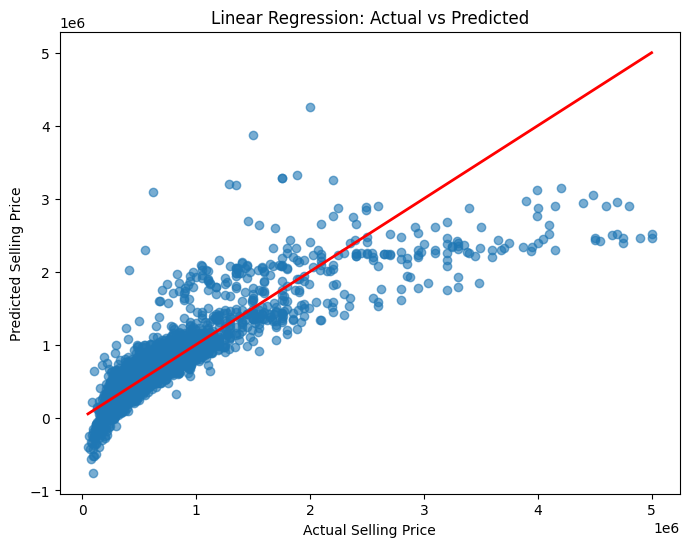

In [317]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

plt.scatter(y_test, y_pred_lr, alpha=0.6)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color="red",
    linewidth=2
)

plt.xlabel("Actual Selling Price")
plt.ylabel("Predicted Selling Price")
plt.title("Linear Regression: Actual vs Predicted")

plt.show()